# Modelado

## Objetivo del notebook

El objetivo de este notebook es entrenar y evaluar distintos modelos de clasificación para predecir el abandono de clientes.

Cada modelo será evaluado utilizando las mismas métricas de rendimiento, lo que permitirá realizar una comparación objetiva y seleccionar el modelo con mejor capacidad predictiva para este problema de negocio.

# 1. Carga de librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modelos de Machine Learning
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluación de modelos
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# 2. Carga de datos

## Objetivo

En este apartado se carga el conjunto de datos procesado y se prepara para el entrenamiento de los modelos de Machine Learning.

A continuación se reproducen las transformaciones definidas en el notebook de preprocesamiento con el fin de obtener los conjuntos de entrenamiento y prueba que serán utilizados durante la fase de modelado.

In [2]:
# Carga de los conjuntos de entrenamiento y prueba preprocesados

X_train = pd.read_csv("../data/processed/X_train_preprocesado.csv")
X_test = pd.read_csv("../data/processed/X_test_preprocesado.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

In [3]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (5634, 45)
X_test: (1409, 45)
y_train: (5634,)
y_test: (1409,)


# 3. Estrategia de modelado

## Objetivo

Antes de entrenar los modelos de Machine Learning, es necesario definir una estrategia de evaluación que permita comparar su rendimiento de forma objetiva.

Todos los modelos se entrenarán utilizando el mismo conjunto de datos y serán evaluados mediante las mismas métricas de clasificación. Este enfoque garantiza una comparación justa y facilita la selección del modelo con mejor capacidad predictiva para el problema de abandono de clientes.

Dado que el conjunto de datos presenta un desbalance entre las clases, además de la precisión global (*Accuracy*), se utilizarán métricas como *Precision*, *Recall*, *F1-score* y *ROC-AUC*, que proporcionan una evaluación más completa del rendimiento de cada modelo.

# 4. Modelo base

## Objetivo

Antes de entrenar modelos de Machine Learning más complejos, resulta recomendable establecer una **línea base** (*baseline*) que sirva como referencia.

Para ello se utilizará un **Dummy Classifier**, un modelo muy sencillo que realiza predicciones sin aprender patrones reales de los datos. El rendimiento obtenido permitirá comprobar si los modelos posteriores aportan una mejora significativa.

In [4]:
def evaluar_modelo(modelo, X_train, X_test, y_train, y_test):
    """
    Entrena un modelo de clasificación y calcula sus principales métricas
    de evaluación sobre el conjunto de prueba.

    Parameters
    ----------
    modelo : estimator
        Modelo de clasificación de Scikit-Learn.

    X_train : pandas.DataFrame
        Variables predictoras del conjunto de entrenamiento.

    X_test : pandas.DataFrame
        Variables predictoras del conjunto de prueba.

    y_train : pandas.Series
        Variable objetivo del conjunto de entrenamiento.

    y_test : pandas.Series
        Variable objetivo del conjunto de prueba.

    Returns
    -------
    dict
        Diccionario con las métricas de evaluación.
    """

    # Entrenamiento del modelo
    modelo.fit(X_train, y_train)

    # Predicciones
    y_pred = modelo.predict(X_test)

    # Probabilidades (si el modelo las soporta)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    resultados = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
    y_test,
    y_pred,
    pos_label="Yes",
    zero_division=0
),
"Recall": recall_score(
    y_test,
    y_pred,
    pos_label="Yes",
    zero_division=0
),
"F1-score": f1_score(
    y_test,
    y_pred,
    pos_label="Yes",
    zero_division=0
),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return resultados

## 4.1 Dummy Classifier

### Objetivo

El **Dummy Classifier** se utiliza como modelo de referencia (*baseline*). Este modelo no aprende patrones a partir de los datos, sino que realiza predicciones siguiendo una estrategia muy sencilla.

Comparar los modelos de Machine Learning con esta línea base permitirá comprobar si realmente aportan capacidad predictiva o si su rendimiento es similar al de un modelo sin aprendizaje.

In [5]:
# Crear el modelo base
dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

# Evaluar el modelo
resultados_dummy = evaluar_modelo(
    modelo=dummy,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

In [6]:
# Crear tabla de resultados
tabla_resultados = pd.DataFrame(
    [resultados_dummy],
    index=["Dummy Classifier"]
)

# Mostrar resultados
tabla_resultados.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Dummy Classifier,0.7346,0.0,0.0,0.0,0.5


### Interpretación

El **Dummy Classifier** constituye la línea base del proyecto. Al predecir siempre la clase mayoritaria (*No*), obtiene una precisión global (*Accuracy*) relativamente elevada debido al desbalance existente en el conjunto de datos.

Sin embargo, es incapaz de identificar clientes que realmente abandonan la compañía, obteniendo valores nulos en **Precision**, **Recall** y **F1-score**, además de un **ROC-AUC** cercano a 0.5, equivalente a realizar predicciones aleatorias.

Estos resultados servirán como referencia para comprobar si los modelos de Machine Learning aportan una mejora real en la capacidad predictiva.

# 5. Modelos de Machine Learning

## 5.1 Regresión logística

### Objetivo

La regresión logística será el primer modelo de Machine Learning evaluado. Se trata de un algoritmo de clasificación lineal ampliamente utilizado como modelo base debido a su sencillez, rapidez de entrenamiento y facilidad de interpretación.

Su rendimiento servirá como referencia para comparar posteriormente modelos más complejos basados en árboles de decisión y técnicas de ensamblado.

In [7]:
# Crear el modelo
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Evaluar el modelo
resultados_logistic = evaluar_modelo(
    modelo=logistic,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

# Añadir resultados a la tabla comparativa
tabla_resultados.loc["Logistic Regression"] = resultados_logistic

# Mostrar tabla actualizada
tabla_resultados.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Dummy Classifier,0.7346,0.0000,0.0000,0.000,0.5000
Logistic Regression,0.8055,0.6572,0.5588,0.604,0.8421


### Interpretación

La **Regresión Logística** mejora significativamente el rendimiento obtenido por el Dummy Classifier en todas las métricas evaluadas.

El modelo alcanza una precisión global superior al 80 % y presenta una buena capacidad para diferenciar entre clientes que abandonan y clientes que permanecen, obteniendo un **ROC-AUC de 0.8421**.

Aunque el **Recall** todavía indica que una parte de los clientes que abandonan no es detectada, este modelo constituye una base sólida sobre la que comparar algoritmos más complejos en los siguientes apartados.

# Predicciones del modelo

### Matriz de confusión

Con el fin de analizar con mayor detalle el comportamiento de la Regresión Logística, se representa la matriz de confusión sobre el conjunto de prueba.

Esta visualización permite identificar el número de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, proporcionando una visión más completa del rendimiento del modelo que las métricas agregadas.

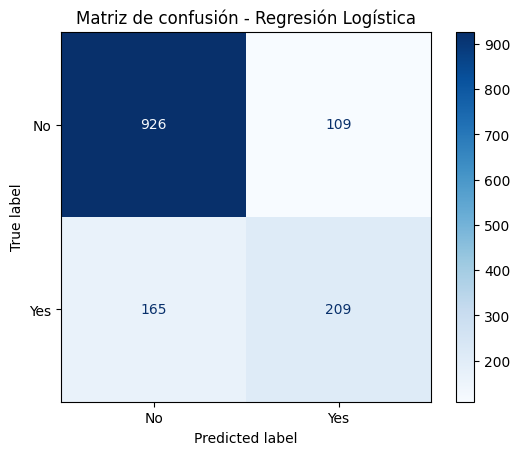

In [8]:
# Predicciones del modelo
y_pred_logistic = logistic.predict(X_test)

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    cmap="Blues"
)

plt.title("Matriz de confusión - Regresión Logística")
plt.show()

### Interpretación

La matriz de confusión permite analizar con mayor detalle el comportamiento del modelo.

En particular, muestra el número de clientes correctamente clasificados y aquellos que han sido clasificados de forma incorrecta, diferenciando entre verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

Este análisis resulta especialmente útil en problemas de predicción de abandono, ya que permite valorar cuántos clientes con riesgo real de churn no han sido detectados por el modelo.

## 5.2 Árbol de decisión

### Objetivo

El Árbol de Decisión es uno de los algoritmos de clasificación más utilizados por su capacidad para capturar relaciones no lineales entre las variables predictoras y la variable objetivo.

Además de ofrecer un modelo fácilmente interpretable, servirá como punto de comparación con algoritmos más avanzados basados en conjuntos de árboles, como Random Forest y XGBoost.

In [9]:
# Crear el modelo
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Evaluar el modelo
resultados_decision_tree = evaluar_modelo(
    modelo=decision_tree,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

# Añadir resultados a la tabla comparativa
tabla_resultados.loc["Decision Tree"] = resultados_decision_tree

# Mostrar tabla actualizada
tabla_resultados.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Dummy Classifier,0.7346,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477


### Interpretación

El **Árbol de Decisión** presenta un rendimiento inferior al obtenido por la Regresión Logística en todas las métricas evaluadas.

Aunque este algoritmo es capaz de capturar relaciones no lineales entre las variables, un único árbol suele presentar una mayor tendencia al sobreajuste, lo que reduce su capacidad de generalización sobre datos no vistos.

Estos resultados justifican la evaluación de modelos de ensamblado, como **Random Forest**, que combinan múltiples árboles de decisión para obtener predicciones más robustas y estables.

## 5.3 Random Forest

### Objetivo

Random Forest es un algoritmo de ensamblado basado en múltiples árboles de decisión. A diferencia de un árbol individual, combina las predicciones de numerosos árboles entrenados sobre diferentes muestras del conjunto de datos, lo que reduce el sobreajuste y mejora la capacidad de generalización del modelo.

Debido a su buen rendimiento en problemas de clasificación con datos tabulares, constituye uno de los modelos de referencia en este tipo de aplicaciones.

In [10]:
# Crear el modelo
random_forest = RandomForestClassifier(
    random_state=42
)

# Evaluar el modelo
resultados_random_forest = evaluar_modelo(
    modelo=random_forest,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

# Añadir resultados a la tabla comparativa
tabla_resultados.loc["Random Forest"] = resultados_random_forest

# Mostrar tabla actualizada
tabla_resultados.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Dummy Classifier,0.7346,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477
Random Forest,0.7864,0.6254,0.4866,0.5474,0.8185


### Interpretación

El **Random Forest** mejora claramente el rendimiento obtenido por un Árbol de Decisión individual, lo que confirma la capacidad de los métodos de ensamblado para reducir el sobreajuste.

Sin embargo, con la configuración utilizada, no consigue superar el rendimiento alcanzado por la Regresión Logística. Todas las métricas de evaluación muestran valores ligeramente inferiores, lo que indica que, para este conjunto de datos, un modelo lineal constituye una alternativa más eficaz.

Estos resultados ponen de manifiesto la importancia de comparar distintos algoritmos antes de seleccionar un modelo, ya que los modelos más complejos no siempre ofrecen un mejor rendimiento.

## 5.4 XGBoost

### Objetivo

XGBoost es uno de los algoritmos de clasificación más utilizados en problemas de datos tabulares debido a su elevada capacidad predictiva y a su eficiencia computacional.

Este modelo utiliza técnicas de *gradient boosting*, construyendo secuencialmente árboles de decisión que corrigen los errores cometidos por los árboles anteriores. Su rendimiento servirá para comprobar si un modelo más avanzado consigue superar a los algoritmos evaluados previamente.

### Preparación de la variable objetivo

A diferencia de los modelos evaluados anteriormente, XGBoost requiere que la variable objetivo esté codificada mediante valores numéricos. Por este motivo, las categorías **"No"** y **"Yes"** se transforman en **0** y **1**, respectivamente, manteniendo el resto del flujo de trabajo sin modificaciones.

In [11]:
# Convertir la variable objetivo a formato numérico
y_train_xgb = y_train.map({"No": 0, "Yes": 1})
y_test_xgb = y_test.map({"No": 0, "Yes": 1})

In [12]:
# Crear el modelo
xgboost = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [13]:
# Entrenamiento
xgboost.fit(X_train, y_train_xgb)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
# Predicciones
y_pred_xgb = xgboost.predict(X_test)
y_prob_xgb = xgboost.predict_proba(X_test)[:, 1]

In [15]:
# Métricas de evaluación
resultados_xgboost = {
    "Accuracy": accuracy_score(y_test_xgb, y_pred_xgb),
    "Precision": precision_score(y_test_xgb, y_pred_xgb),
    "Recall": recall_score(y_test_xgb, y_pred_xgb),
    "F1-score": f1_score(y_test_xgb, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test_xgb, y_prob_xgb)
}

In [16]:
# Añadir resultados a la tabla comparativa
tabla_resultados.loc["XGBoost"] = resultados_xgboost

# Mostrar resultados
tabla_resultados.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Dummy Classifier,0.7346,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477
Random Forest,0.7864,0.6254,0.4866,0.5474,0.8185
XGBoost,0.7729,0.5823,0.5107,0.5442,0.8152


# 6. Comparación de modelos

## Objetivo

Una vez entrenados todos los modelos, se comparan sus métricas de evaluación con el objetivo de identificar el algoritmo que ofrece el mejor rendimiento para la predicción del abandono de clientes.

La comparación se realiza utilizando las mismas métricas para todos los modelos, garantizando una evaluación objetiva y permitiendo seleccionar el modelo con mayor capacidad predictiva.

In [17]:
tabla_resultados.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Dummy Classifier,0.7346,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477
Random Forest,0.7864,0.6254,0.4866,0.5474,0.8185
XGBoost,0.7729,0.5823,0.5107,0.5442,0.8152


### Interpretación

Los resultados muestran que la **Regresión Logística** obtiene el mejor rendimiento global entre todos los modelos evaluados.

Aunque modelos más complejos como **Random Forest** y **XGBoost** suelen ofrecer un excelente comportamiento en problemas de clasificación, en este conjunto de datos no consiguen superar al modelo lineal en ninguna de las métricas analizadas.

Este resultado pone de manifiesto que un mayor nivel de complejidad no implica necesariamente una mejor capacidad predictiva. La elección del modelo debe basarse siempre en una comparación objetiva utilizando métricas adecuadas y no únicamente en la sofisticación del algoritmo.

# 7. Selección del mejor modelo

## Modelo seleccionado

Tras comparar el rendimiento de los distintos algoritmos de clasificación, se selecciona la **Regresión Logística** como modelo final de este notebook.

Este modelo obtiene los mejores resultados en **Accuracy**, **Precision**, **Recall**, **F1-score** y **ROC-AUC**, demostrando una mayor capacidad para generalizar sobre datos no vistos.

En el siguiente notebook se optimizará este modelo mediante técnicas de ajuste de hiperparámetros y se realizará una evaluación más detallada de su rendimiento.

# 8. Conclusiones

## Conclusiones

En este notebook se han entrenado y comparado distintos modelos de clasificación para predecir el abandono de clientes utilizando el mismo conjunto de datos preprocesado y las mismas métricas de evaluación.

Los resultados muestran que la **Regresión Logística** obtiene el mejor rendimiento global entre los modelos evaluados, superando al Árbol de Decisión, Random Forest y XGBoost en todas las métricas analizadas.

No obstante, esta comparación se ha realizado utilizando configuraciones base de cada algoritmo. En el siguiente notebook se llevará a cabo la optimización de los modelos más prometedores mediante técnicas de ajuste de hiperparámetros, con el objetivo de comprobar si es posible mejorar su capacidad predictiva.